![TecNM](https://drive.google.com/uc?id=1HP9R3V9XnozjtY08gGdKhoCKo76MKgLr)

---
<div align="center">

  ## **Machine Learning y Deep Learning**

  ### **Unidad 2 - Modelos de Aprendizaje Supervisado**

  #### **Practica No. 1 - Implementación del Modelo de Regresión Lineal Simple**

  ##### **Docente:** Dr. José Gabriel Rodríguez Rivas
  ##### **Estudiante:** Cristopher Joshua Reyes Gutiérrez

</div>

---


### **1. Introducción**
¿Qué pasaría si la ciencia pudiera anticipar el futuro con precisión matemática? En la era actual, dominada por los datos masivos, esta premisa ha dejado de ser una utopía para convertirse en una realidad tangible. El aprendizaje automático (*Machine Learning*) se ha consolidado como la herramienta principal para navegar en esta complejidad, y en el corazón de esta revolución analítica se encuentran los modelos de regresión.

Estos algoritmos se rigen como motores matemáticos fundamentales para predecir variables continuas y descubrir las relaciones estocásticas más complejas en grandes volúmenes de información. La presente investigación invita a explorar el algoritmo predictivo más fascinante y poderoso por su elegancia paramétrica: el **Modelo de Regresión Lineal Simple**. Esta herramienta establece los cimientos lógicos de la interpretabilidad al modelar la relación lineal entre variables, permitiéndonos transformar datos históricos en proyecciones precisas para la toma de decisiones.

### **2. Objetivos de la Investigación**

#### **2.1 Objetivo General**
Analizar de manera detallada la arquitectura matemática, los mecanismos de optimización y el rendimiento predictivo del modelo de regresión lineal simple mediante su implementación en Python, con el propósito de establecer criterios técnicos y estadísticos claros para la estimación de variables continuas.

#### **2.2 Objetivos Específicos**
* **Describir** los fundamentos paramétricos de la regresión lineal, determinando empíricamente su nivel de precisión a través de métricas de error.
* **Evaluar** la capacidad de la variable predictora (*city-mpg*) para explicar la variabilidad de la variable objetivo (*price*) mediante el cálculo del coeficiente de determinación $R^2$.
* **Diagnosticar** visualmente el equilibrio entre el sesgo y la varianza comparando las distribuciones reales frente a las predicciones generadas por el modelo.

### **3. Antecedentes y Marco Teórico**
El Modelo de Regresión Lineal Simple representa la aproximación analítica más elemental y, bajo ciertas condiciones, la más robusta dentro del modelado predictivo. Su concepción matemática se enfoca en identificar la línea recta que mejor describe la dispersión de un conjunto de datos, con el imperativo algebraico de minimizar la suma de los errores.

#### **3.1 Formulación Matemática**
Desde una perspectiva estocástica, la relación entre una variable dependiente ($y$) y una predictora ($x$) se describe mediante la ecuación:
$$y_{i} = \beta_{0} + \beta_{1}x_{i} + \epsilon_{i}$$

Donde:
* **$\beta_{0}$ (Intersección):** Indica el valor esperado de $y$ cuando $x$ es igual a cero.
* **$\beta_{1}$ (Pendiente):** Señala cuánto se espera que cambie $y$ por cada aumento de una unidad en $x$.
* **$\epsilon_{i}$ (Error Aleatorio):** Representa la diferencia entre el valor real y el estimado, capturando la variabilidad que el modelo no puede explicar.

#### **3.2 Optimización por Mínimos Cuadrados Ordinarios (MCO)**
A diferencia de algoritmos de "caja negra", el modelo lineal es totalmente interpretable. Su mecanismo operativo se fundamenta en los **Mínimos Cuadrados Ordinarios (MCO)**, un algoritmo que calcula los estimadores puntuales que garantizan la minimización global de la Suma Residual de Cuadrados (SRC), asegurando que la línea trazada sea la que mejor se ajuste a la tendencia general de los datos.

## **4. Descripción Metodológica de la Práctica**
A continuación, se desarrolla el flujo de trabajo para la carga, preparación, entrenamiento y validación del modelo utilizando el conjunto de datos de precios de automóviles.



### **4.1 - Importación de las Librerías Necesarias**
En primer lugar, se procede a la importación de las bibliotecas fundamentales para el análisis de datos. Se utiliza **Pandas** para la manipulación de los datos, **NumPy** para operaciones numéricas, y las librerías **Matplotlib** y **Seaborn** para la generación de gráficos que faciliten la comprensión de la distribución de los datos.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

### **4.2 - Carga de Datos Mediante Google Drive**
Se realiza la carga del conjunto de datos "**Automóviles**" desde una fuente remota. Los datos crudos son almacenados en un estructura de tipo ***DataFrame*** de Pandas, lo cual permite su manipulación programática. Adicionalmente, se verifica la correcta lectura del archivo mediante una visualización preliminar de las primeras filas y la dimensión total de la matriz de datos.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_url = "1p3ha0Nvv46PHZoB9ReBGLu8xQyDe8m0Y"
url = f"https://drive.google.com/uc?id={file_url}"
df = pd.read_csv(url)

### **4.3 - Selección de Atributos y Definición**

En esta fase, se aisla las variables fundamentales para el análisis. Bajo el paradigma de la regresión lineal simple, se selecciona una única característica predictora y una etiqueta objetivo:

* **Variable Predictora (X)**: *city-mpg*, representa el rendimiento de combustible en ciudad. Se define como una matriz de características.

* **Variable Objetivo (y)**: *price*, constituye el valor monetario del vehículo que el modelo intentará estimar.



In [4]:
X = df[['city-mpg']]
y = df['price']

### **4.4 - Protocolo de Partición de Datos (Hold-out Validation)**

Para evitar el fenómeno del sobreajuste (*overfitting*) y asegurar que el modelo sea capaz de generalizar ante datos no vistos, aplicamos una partición estocástica del dataset. Se reserva un **20%** de las muestras para la fase de prueba (*Testing*), mientras que el **80%** restante se destina al entrenamiento del algoritmo. Se establece una semilla de aleatoriedad (random_state=42) para permitir la reproducibilidad de los experimentos.



In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **4.5 - Entrenamiento Mediante Mínimos Cuadrados Ordinarios (MCO)**
Se procede a la instanciación del algoritmo de Regresión Lineal. Durante el entrenamiento, el modelo optimiza los coeficientes $\beta_0$ e $\beta_1$ buscando minimizar la suma de los residuos al cuadrado, encontrando así la recta de mejor ajuste para los datos de entrenamiento




In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### **4.6 - Inferencia y Cálculo de Métricas de Desempeño**
Una vez ajustado el modelo, se realiza la inferencia sobre el conjunto de prueba para obtener las métricas de error y bondad de ajuste.
* **Error Cuadrático Medio (MSE):** Cuantifica la varianza de los residuos
* **Raíz del Error Cuadrático Medio (RMSE):** Facilita la interpretación al expresar el error en las unidades monetarias originales.
* **Coeficiente de Determinación ($R^2$):** Indica la proporción de la varianza explicada por el modelo.

In [7]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

MSE: 74223480.07
RMSE: 8615.30
R2 Score: 0.39


### **4.7 - Diagnóstico Visual de la Distribución de Residuos**
La validación final se realiza mediante el contraste gráfico de las curvas de densidad. Esto permite detectar visualmente si el modelo paramétrico logra capturar la naturaleza de los datos o si presenta un sesgo elevado

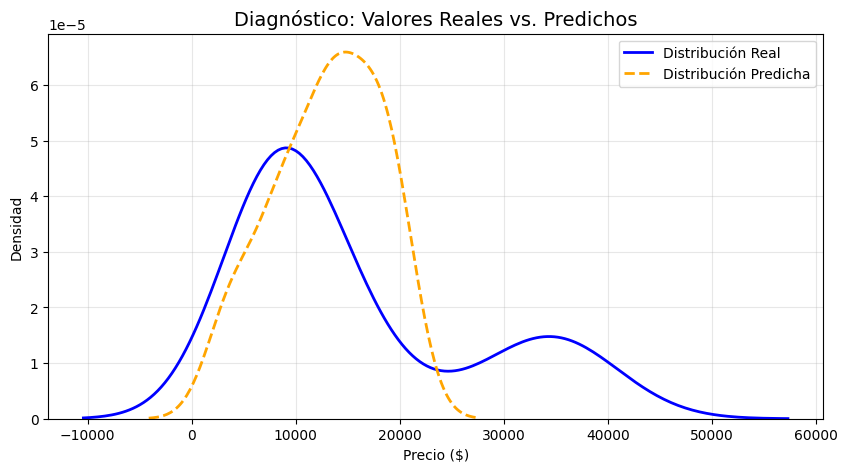

In [8]:
plt.figure(figsize=(10, 5))
sns.kdeplot(y_test, label='Distribución Real', color='blue', linewidth=2)
sns.kdeplot(y_pred, label='Distribución Predicha', color='orange', linewidth=2, linestyle='--')
plt.title("Diagnóstico: Valores Reales vs. Predichos", fontsize=14)
plt.xlabel("Precio ($)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **5 - Conclusiones y Análisis de Hallazgos**

Tras la implementación y el análisis del modelo de Regresión Lineal Simple para predecir el precio de los automóviles basándose en su rendimiento en ciudad, se logran concluir los siguientes puntos:
* **Insuficiencia del Modelo Lineal**: El coeficiente de determinación de 0.39 indica que la variable *city-mpg* solo explica el 39% de la variación en los precios, dejando un 61% de la variabilidad sujeta a factores no incluidos en el modelo.
* **Magnitud del Error Predictivo**: El RMSE obtenido de aproximadamente **8,615** se considera sumamente elevado para fines prácticos. Dado que una gran proporción de vehículos se sitúan en el rango de 8,000 a 16,000, este error puede representar una desviación promedio de hasta el 71.79% respecto al valor real.
* **Detección de Sesgo Estructural**: El diagnóstico visual revela que el modelo es incapaz de capturar la naturaleza bimodal de los precios reales. Mientras que los datos observados muestran un pico secundario para vehículos de gama alta (cerca de **35,000**), el modelo genera una distribución unimodal estrecha, fallando sistemáticamente en la predicción de autos de alto costo.
* **Propuesta de Mejora**: Se concluye que la relación entre el rendimiento y el precio no es estrictamente lineal paramétrica. Se recomienda transitar hacia modelos de Regresión Múltiple, integrando variables adicionales como la potencia del motor (horsepower) o el tamaño del motor (enginesize) para reducir el sesgo del modelo.
## **6 - Referencias Bibliográficas**        
* Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5-32.Montgomery, D. C., Peck, E.
* A., & Vining, G. G. (2003). Introducción al análisis de regresión lineal. CECSA.
* Revista Chilena de Anestesia. (2014). Regresión lineal.
* Vapnik, V. N. (2000). The nature of statistical learning theory. Springer.